# 2D con $\varphi(r,z)$ — cómo usarlo (Calbuco 2015)

El 2D viejo (`RIconduit2D_FD.py`, `mainconduit5_7.ipynb`) tiene $u_m(r,z)$ pero $\varphi=\varphi(z)$ plano.
Este notebook usa **`RIconduit2D_phi_r.py`**: reducción $u_r=0$, $P=P(z)$, y campos
$\varphi(r,z)$, $N(r,z)$, $\xi(r,z)$. Paso adaptativo en $z$ y umbrales suaves.

Los límites de régimen $\varphi_1,\varphi_2,\varphi_{\mathrm{crit}}$ **no se escriben a mano**:
se calculan como en el 1D, con un $Ca_\ast$ de referencia (ver el PDF, I.E).

Acá corre **una marcha** (`max_count=1`), no el tiro completo. Eso tarda unos segundos.
Para disparar sobre $v_{\mathrm{in}}$: `max_count=8` o más.

In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt

from RIconduit2D_phi_r import RIconduit2D_phi_r_f, radial_grid
from calbuco2015d import radius1, overP1, h2o1, T1, xi1, H, pfinal

## 1. Datos de Calbuco y una marcha

`RIconduit2D_phi_r_f` devuelve un diccionario:

- `z` $(n_z,)$
- `P` $(n_z,)$ — $P=P(z)$
- `phi`, `Nd`, `xi`, `um`, `ug` — shape $(n_z,\,N_r)$
- `r` — malla radial
- `limphi1`, `limphi2`, `phicrit`, `Ca` — umbrales calculados

In [2]:
out = RIconduit2D_phi_r_f(
    radius=radius1,          # 16 m
    Pressure=overP1,         # 5 MPa de sobrepresión
    wt=h2o1,                 # 4 % peso de agua
    Temperature=T1,          # 1243.15 K
    content_crystal=xi1,     # 0.25
    N_r=10,
    max_steps=160,
    max_count=1,             # solo marcha; poné >1 para el tiro
    verbose=True,
)

z, r = out["z"], out["r"]
print(f"nodos: z={z.size}  r={r.size}")
print(f"z: {z[0]:.0f} → {z[-1]:.1f} m    P: {out['P'][0]/1e6:.1f} → {out['P'][-1]/1e6:.2f} MPa")
print(
    f"umbrales (cuenta de Ca, como el 1D):  "
    f"Ca={out['Ca']:.3e}  φ1={out['limphi1']:.3f}  "
    f"φ2={out['limphi2']:.3f}  φcrit={out['phicrit']:.3f}"
)


Count = 1  vinicial = 10.00000
  [phi_r] pasos=160 rechazos=6 z=-3185.1 P=8.683e+07 phi_eje=0.0338 phi_pared=0.0085 dphi=2.5372e-02
nodos: z=229  r=10
z: -7000 → -3185.1 m    P: 183.5 → 86.83 MPa
umbrales (cuenta de Ca, como el 1D):  Ca=2.425e+00  φ1=0.223  φ2=0.233  φcrit=0.709


## 2. $\varphi$ en el eje vs junto a la pared

En el 2D viejo estas dos curvas coinciden. Acá no: cada nodo radial tiene su $\varphi$.

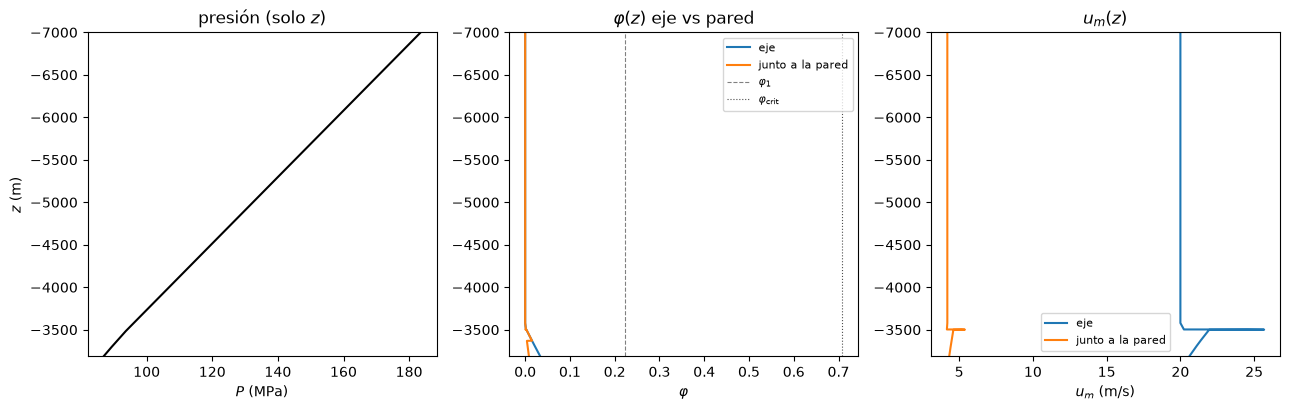

max |φ_eje − φ_pared| = 2.5372e-02


In [3]:
fig, ax = plt.subplots(1, 3, figsize=(13, 4.2))

ax[0].plot(out["P"] / 1e6, z, "k")
ax[0].set_xlabel("$P$ (MPa)")
ax[0].set_ylabel("$z$ (m)")
ax[0].set_title("presión (solo $z$)")

ax[1].plot(out["phi"][:, 0], z, label="eje")
ax[1].plot(out["phi"][:, -2], z, label="junto a la pared")
ax[1].axvline(out["limphi1"], ls="--", c="0.5", lw=0.8, label=r"$\varphi_1$")
ax[1].axvline(out["phicrit"], ls=":", c="0.3", lw=0.8, label=r"$\varphi_{\mathrm{crit}}$")
ax[1].set_xlabel(r"$\varphi$")
ax[1].set_title(r"$\varphi(z)$ eje vs pared")
ax[1].legend(fontsize=8)

ax[2].plot(out["um"][:, 0], z, label="eje")
ax[2].plot(out["um"][:, -2], z, label="junto a la pared")
ax[2].set_xlabel(r"$u_m$ (m/s)")
ax[2].set_title(r"$u_m(z)$")
ax[2].legend(fontsize=8)

# Calbuco: H=-7000 m. Si z[0] se va a -70 km, el gráfico queda como el de antes.
z_lo = max(float(np.min(z)), float(H) - 1.0)
for a in ax:
    a.set_ylim(min(0.0, float(np.max(z))), z_lo)
fig.tight_layout()
plt.show()

dphi = out["phi"][:, 0] - out["phi"][:, -2]
print(f"z ∈ [{z.min():.1f}, {z.max():.1f}] m   (H={H:.0f} m; z=0 es la boca)")
print(f"max |φ_eje − φ_pared| = {np.max(np.abs(dphi)):.4e}")

## 3. Campo $\varphi(r,z)$ y perfiles $u_m(r)$

El mapa de la izquierda es lo nuevo: $\varphi$ cambia con $r$. A la derecha, el Poiseuille en tres cotas.

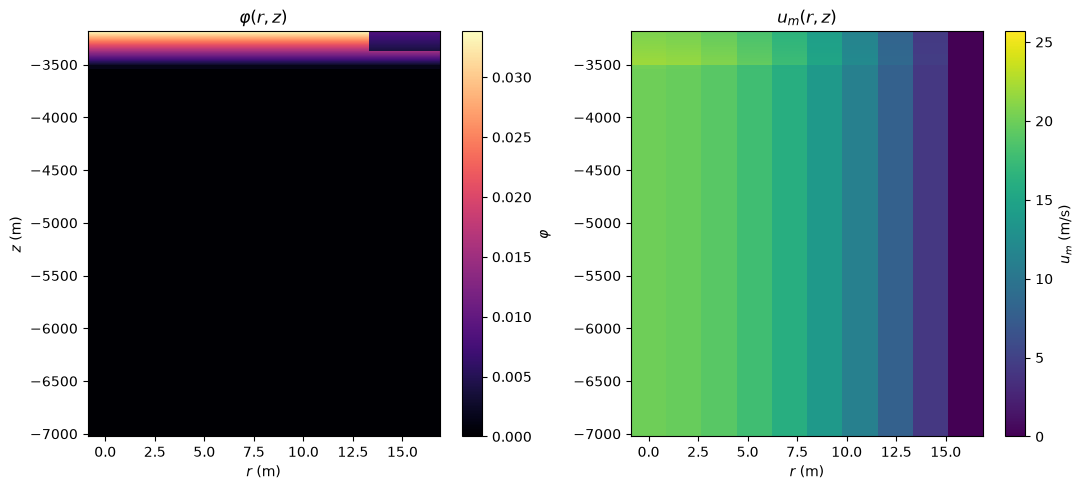

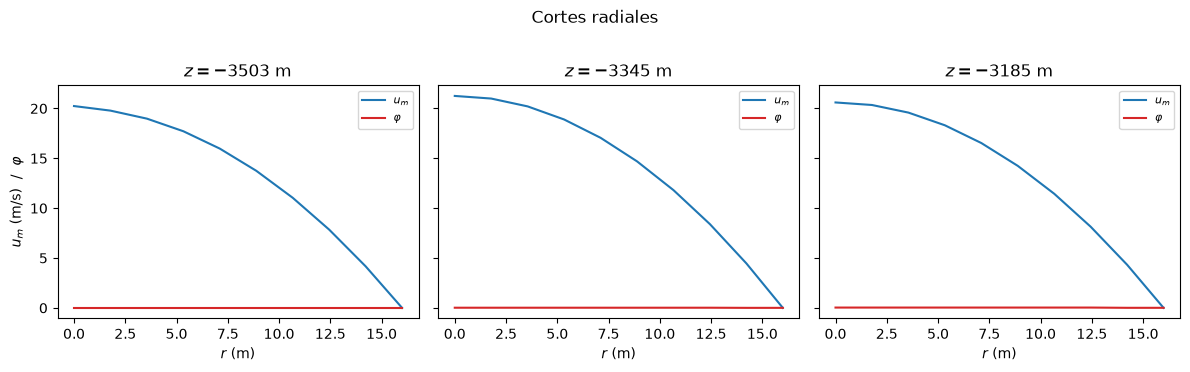

In [4]:
R_mesh, Z_mesh = np.meshgrid(r, z)

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
c0 = axes[0].pcolormesh(R_mesh, Z_mesh, out["phi"], shading="auto", cmap="magma")
fig.colorbar(c0, ax=axes[0], label=r"$\varphi$")
axes[0].set_xlabel("$r$ (m)")
axes[0].set_ylabel("$z$ (m)")
axes[0].set_title(r"$\varphi(r,z)$")

c1 = axes[1].pcolormesh(R_mesh, Z_mesh, out["um"], shading="auto", cmap="viridis")
fig.colorbar(c1, ax=axes[1], label=r"$u_m$ (m/s)")
axes[1].set_xlabel("$r$ (m)")
axes[1].set_title(r"$u_m(r,z)$")
fig.tight_layout()
plt.show()

gas = np.where(out["phi"].max(axis=1) > 1e-3)[0]
if gas.size >= 3:
    idxs = [gas[0], gas[len(gas) // 2], gas[-1]]
else:
    idxs = [0, len(z) // 2, -1]

fig, axes = plt.subplots(1, len(idxs), figsize=(4 * len(idxs), 3.6), sharey=True)
for ax, j in zip(axes, idxs):
    ax.plot(r, out["um"][j], "C0", label=r"$u_m$")
    ax.plot(r, out["phi"][j], "C3", label=r"$\varphi$")
    ax.set_title(f"$z={z[j]:.0f}$ m")
    ax.set_xlabel("$r$ (m)")
    ax.legend(fontsize=8)
axes[0].set_ylabel(r"$u_m$ (m/s)  /  $\varphi$")
fig.suptitle("Cortes radiales", y=1.02)
fig.tight_layout()
plt.show()

## 4. Tiro (opcional)

La marcha de arriba fija $v_{\mathrm{in}}=10\,\mathrm{m/s}$. El 1D busca $v_{\mathrm{in}}$ para que en la boca se cumpla $P\approx P_{\mathrm{atm}}$ o el choque sónico.

```python
out = RIconduit2D_phi_r_f(
    radius=radius1, Pressure=overP1, wt=h2o1,
    Temperature=T1, content_crystal=xi1,
    N_r=12, max_steps=2500, max_count=8,   # bisección sobre vinicial
)
```

Eso tarda más (cada count es una marcha hasta $z=0$). Los umbrales $\varphi_1,\varphi_{\mathrm{crit}}$ se **recalculan** en cada count porque $Ca_\ast$ depende de $v_{\mathrm{in}}$.

## 5. Si \(P\) en la boca está alta: por qué, y qué mover

\(z=0\) es la boca. \(P_{\mathrm{atm}}\approx 0.10\,\mathrm{MPa}\).
Con \(R=16\,\mathrm{m}\) (Calbuco) un tiro sin fricción suficiente sale a \(15{-}30\,\mathrm{MPa}\). No es que \(z=0\) esté mal: sobra presión.

Tres términos, en orden:

1. **\(P_i\) es litostática de corteza.** \(P_i=\rho_{\mathrm{crust}}g|H|+\Delta P\) con \(\rho_{\mathrm{crust}}=2600\,\mathrm{kg/m^3}\), \(H=-7000\,\mathrm{m}\), \(\Delta P=5\,\mathrm{MPa}\) \(\Rightarrow P_i\approx 183.5\,\mathrm{MPa}\). El magma vale \(\rho_m\approx 2460\). Columna de fundido puro, sin fricción: \(P(0)\approx P_i-\rho_m g|H|\approx 14\,\mathrm{MPa}\). Esos \(14\,\mathrm{MPa}\) son \((\rho_{\mathrm{crust}}-\rho_m)g|H|+\Delta P\).
2. **El gas aligera la columna.** \(\partial_z P= -(\rho_{\mathrm{mix}}g+F_{mw})\). Si \(\varphi\) crece, \(\rho_{\mathrm{mix}}\) cae y el gradiente hidrostático se debilita: \(P(0)\) sube respecto al fundido puro (de ahí los \(20{-}30\,\mathrm{MPa}\)).
3. **La fricción tiene que comerse ese resto.** En el 1D, \(F_{mw}=c_g\mu u/R^2\) con \(u=q/\rho_{\mathrm{mix}}\) (crece al expandir). Acá, si se usaba \(\tau=(1-\varphi)\mu\partial_r u\) de la pared, \((1-\varphi)\) apagaba \(F_{mw}\) justo cuando más se necesita. Ahora \(F_{mw}\) es la del 1D.

Lo que más baja \(P(0)\):

| Parámetro | Hacia dónde | Efecto |
|---|---|---|
| **`radius`** | más chico (\(8\), \(10\,\mathrm{m}\)) | \(1/R^2\): el más fuerte |
| `Temperature` | más baja | \(\mu\) de Giordano sube |
| `content_crystal` | más cristales | \(\mu\) sube |
| `wt` | más agua | más gas, más expansión (el 1D lo usa cerca de la boca) |
| `Pressure` (`overP`) | más chica | \(P_i\) más baja, menos que bajar |
| `vinicial` | más grande | más fricción, pero acá mueve poco |

Calbuco en el paper es \(R=16\,\mathrm{m}\). Achicar el radio **cambia el volcán**, no “arregla” el modelo.
El 1D cierra el tiro a \(R=16\) porque expande el gas; eso todavía no está bien en el 2D.

```python
# mismo Calbuco, conducto más angosto
out8 = RIconduit2D_phi_r_f(
    radius=8.0, Pressure=overP1, wt=h2o1,
    Temperature=T1, content_crystal=xi1,
    N_r=10, max_steps=2500, max_count=1, vinicial=10.0,
)
print(out8["z"][-1], out8["P"][-1] / 1e6)   # z y P en MPa
```
